In [68]:
from koala.pointsets import uniform
from koala import graph_utils as gu
from koala import plotting as pl
from koala.voronization import generate_lattice
from koala.flux_finder import fluxes_from_ujk, ujk_from_fluxes
from koala.lattice import Lattice
from scipy import linalg as la
from pfapack.pfaffian import pfaffian

from koala.graph_color import vertex_color
from koala import example_graphs as eg
from dimer_models.koala_plantri import plantri_to_koala, plantri_generator, read_plantri
from dimer_models.lattice_generation import (
    bipartite_squarefull,
    reduce_bipartite,
)

from dimer_models.lattice_generation import expand_edges_to_squares
from dimer_models.kasteleyn import (
    kasteleyn_matrix,
    find_kasteleyn_number,
    find_local_dimer_probability,
)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from copy import copy

In [69]:
# def plaq_shrinker(lattice, plaqs):
#     positions = lattice.vertices.positions
#     edges = lattice.edges.indices
#     crossing = lattice.edges.crossing

#     for plaq in plaqs:
#         vertices = lattice.plaquettes[plaq].vertices
#         center = lattice.plaquettes[plaq].center
#         edges_in_plaq = lattice.plaquettes[plaq].edges

#         vectors = lattice.edges.vectors[edges_in_plaq]*lattice.plaquettes[plaq].directions


#         for j,vertex in enumerate(vertices):
#             ind = np.roll(np.array(np.arange(len(vertices))), -j)
#             print(vertices[ind])

#             vector_to_center = 0
#         break

#     return Lattice(positions, edges, crossing)


# lx1 = plaq_shrinker(lattice, np.where(plaq_labels == 1)[0])
# pl.plot_edges(lx1)

0.1741168348327094 0.5100946040631107


<Axes: >

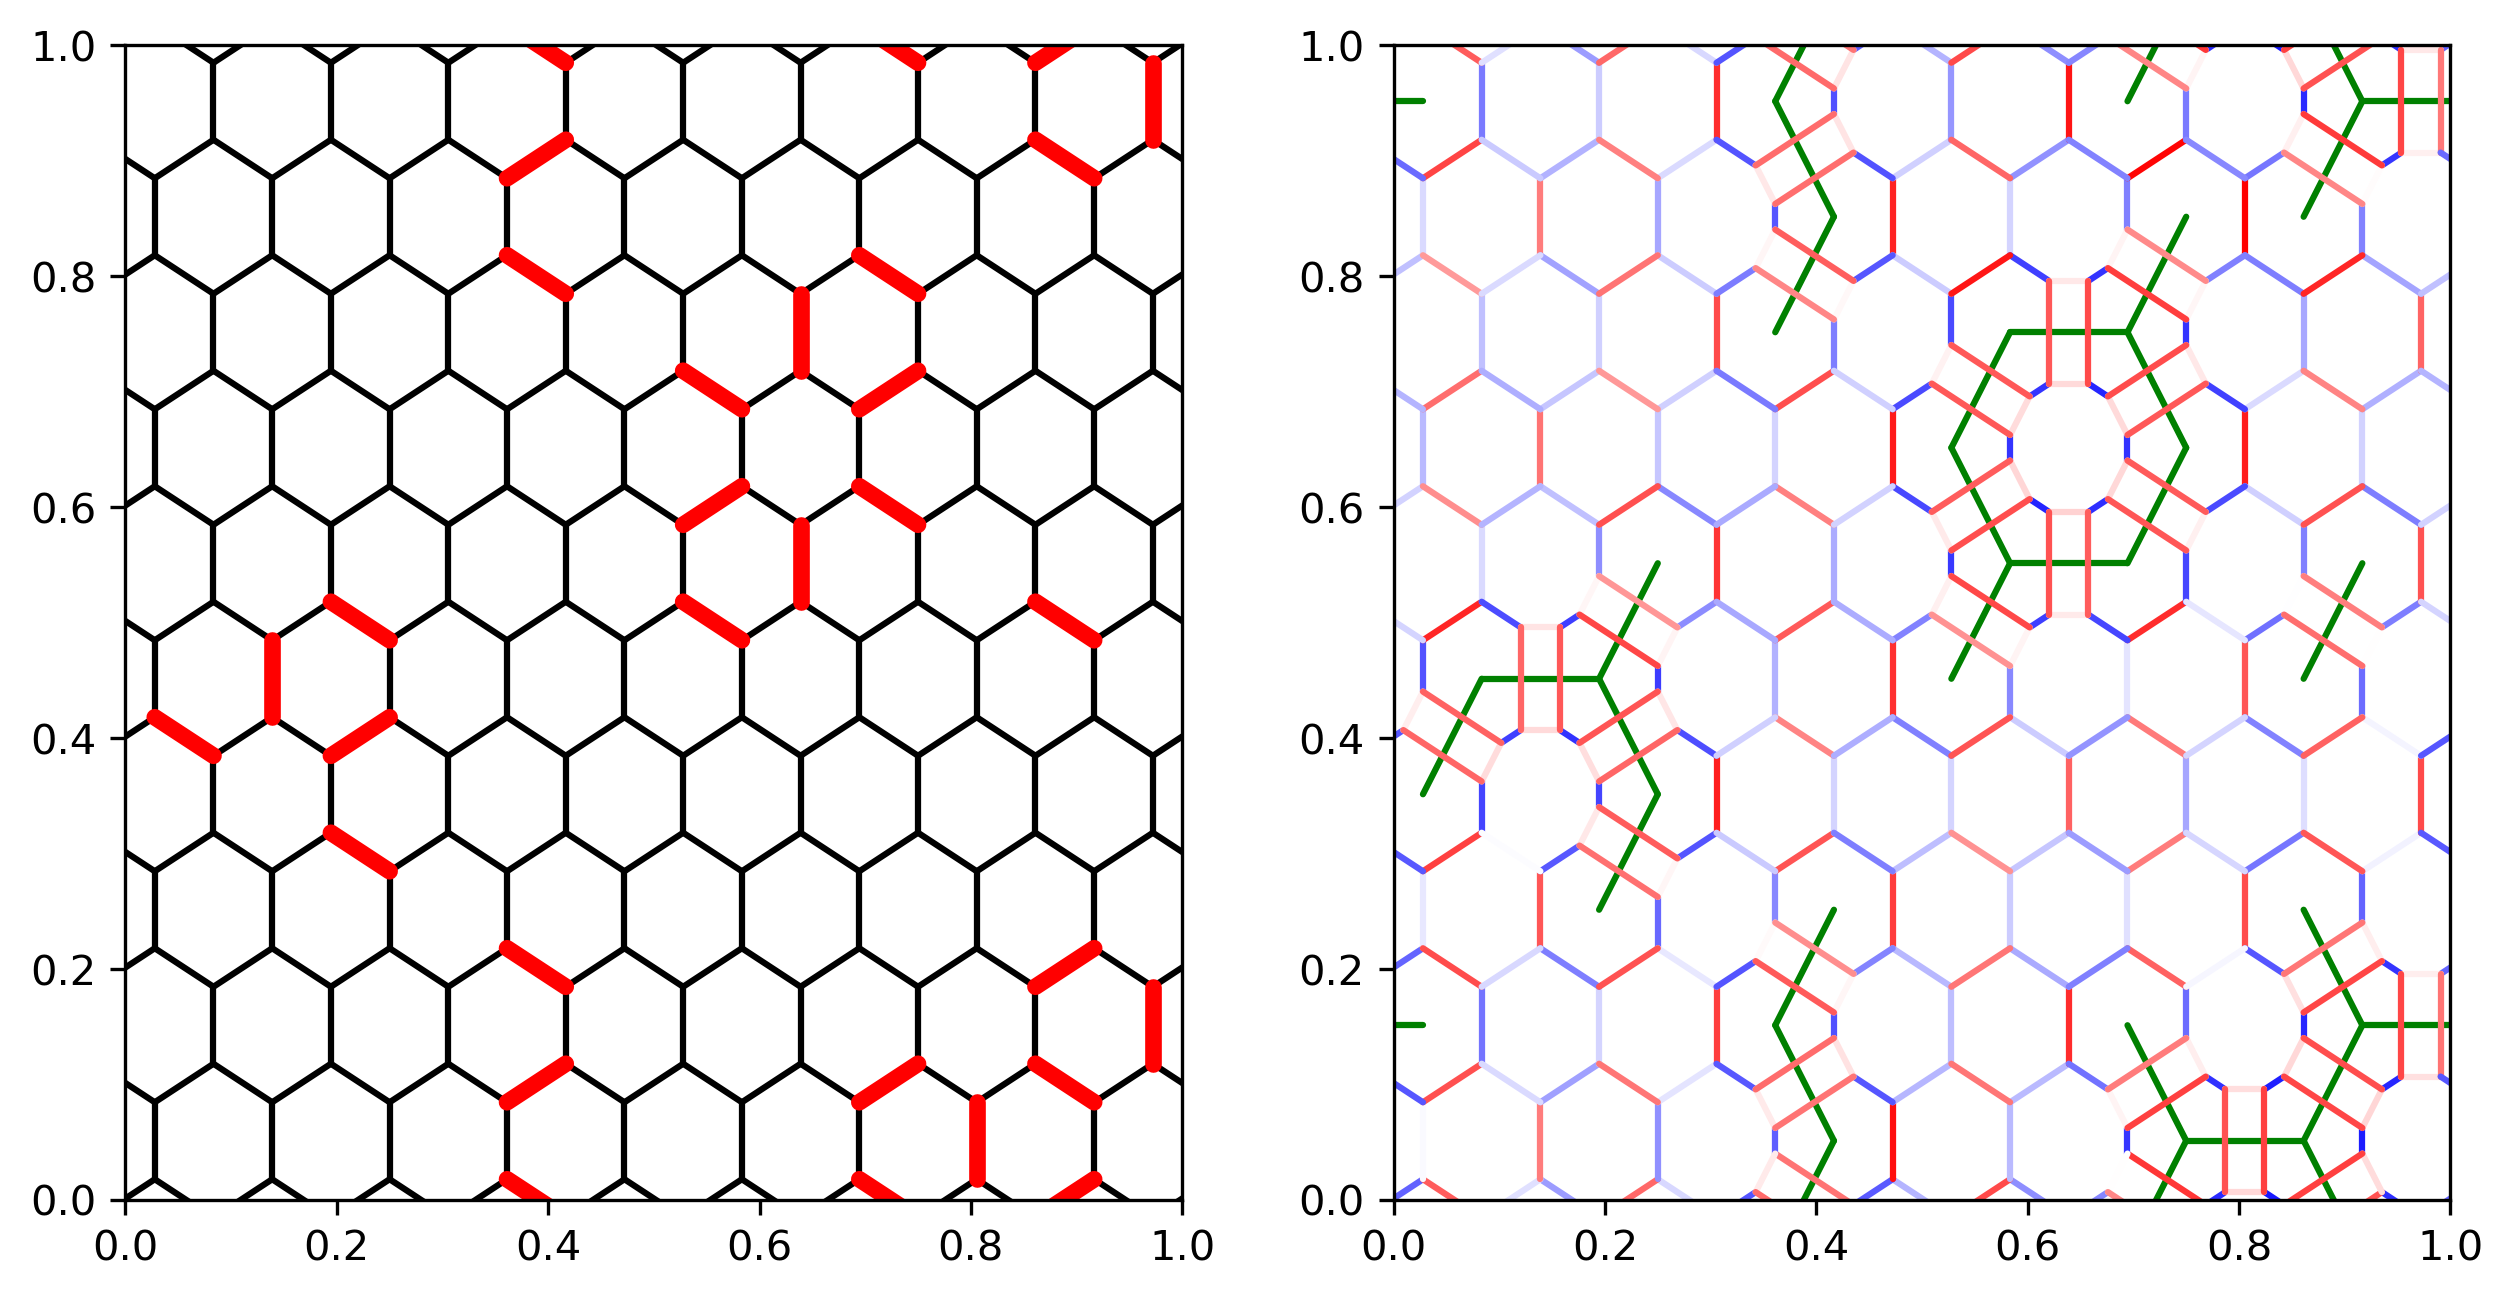

In [ ]:
n = 9
window = 0.3

center = 0.5 + 1 / (4 * n)
lattice = eg.honeycomb_lattice(n)
edge_centers = np.mean(lattice.vertices.positions[lattice.edges.indices], axis=1)

# kitaev edge labels
edge_angles = (
    np.arctan2(lattice.edges.vectors[:, 1], lattice.edges.vectors[:, 0]) % np.pi
)
_, edge_labels = np.unique(np.round(edge_angles, 2), return_inverse=True)

# kekule edge labels
dual = gu.make_dual(lattice, reg_steps=0)
plaq_labels = vertex_color(dual.edges.indices, 3)[1]
kekule_labels = plaq_labels[lattice.edges.adjacent_plaquettes].sum(axis=1) - 1


mask = gu.dimerise(lattice, 3730)[-1] * (kekule_labels == 0)
# mask = (kekule_labels ==0)

# edges_to_expand = lattice.plaquettes[85].edges[::2]
# mask = np.isin(np.arange(lattice.n_edges), edges_to_expand)

l2 = expand_edges_to_squares(lattice, np.where(mask)[0])
# l2 = gu.com_relaxation(l2)


fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=300)
pl.plot_edges(lattice, ax=ax[0])
pl.plot_edges(
    lattice,
    labels=kekule_labels,
    subset=np.where(mask),
    ax=ax[0],
    color_scheme=["r", "y", "b"],
    linewidth=4,
)


probs = find_local_dimer_probability(l2) - (1 / 3)
print(min(probs + 1 / 3), max(probs + 1 / 3))
probs = 0.5 * probs / np.max(np.abs(probs))  # Normalize to range [-1, 1]


edge_labels = np.arange(l2.n_edges)
cmap = plt.get_cmap("bwr")
color_scheme = cmap(probs + 0.5)  # Shift to center around 0

pl.plot_edges(
    l2,
    ax=ax[1],
    labels=edge_labels,
    color_scheme=color_scheme,
    # linewidth=3,
)

pl.plot_edges(
    dual, subset=np.where(mask)[0], ax=ax[1], color_scheme=["g", "y"], zorder=-10
)
# pl.plot_edges(l2, ax=ax[1], linewidth=2)

In [ ]:
np.sum([p.n_sides % 2 for p in l2.plaquettes])

np.int64(0)